In [4]:
import sys
import os
project_root = os.path.abspath('..')
sys.path.append(project_root)
from src import AdversarialObjectDetection, add_noise, compare_detections, test_noise_defense_with_iou
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = AdversarialObjectDetection()
image_url = "..\\leftImg8bit\\test\\berlin\\berlin_000000_000019_leftImg8bit.png"
TARGET_CLASS = 20
noise_configs = [
    {'type': 'gaussian', 'mean': 0, 'std': 10},
    {'type': 'salt_and_pepper', 'density': 0.05},
    {'type': 'salt_and_pepper', 'density': 0.1},
    {'type': 'speckle', 'intensity': 0.2},
    {'type': 'poisson', 'scale': 1.0}
]
results = test_noise_defense_with_iou(
    detector=detector,
    image_path=image_url,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    num_iterations=3
)

c:\Users\victo\Documents\Workspaces\thesis_project\env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\victo\Documents\Workspaces\thesis_project\env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model


In [6]:
print(results['noise_tests'][0]['adversarial_comparison']['average_iou'])

0.34493715


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = AdversarialObjectDetection()
import glob
test_images = glob.glob("..\\leftImg8bit\\test\\berlin\\*.png")[:10]  
print(f"Found {len(test_images)} test images")

# Test parameters
TARGET_CLASS = 20
noise_configs = [
    {'type': 'gaussian', 'mean': 0, 'std': 5},
    {'type': 'salt_and_pepper', 'density': 0.05},
    {'type': 'speckle', 'intensity': 0.2},
    {'type': 'poisson', 'scale': 1.0}
]

iou_types = ["standard", "giou"]

Loading model
Found 10 test images


In [8]:
def batch_test_with_loops(detector, image_paths, target_class, noise_configs, 
                          iou_types, num_iterations=3, confidence_threshold=0.5):
    """
    Loop through images and IoU types, collect all IoU scores
    Fixed IoU threshold just for matching, not for filtering analysis
    """
    all_results = []
    total_tests = len(image_paths) * len(iou_types)
    test_count = 0
    
    for image_path in image_paths:
        image_name = Path(image_path).name
        
        for iou_type in iou_types:
            test_count += 1
            if test_count % 50 == 0:
                print(f"Processing test {test_count}/{total_tests}: Image={image_name}, IoU Type={iou_type}")
            
            try:
                result = test_noise_defense_with_iou(
                    detector=detector,
                    image_path=image_path,
                    target_class=target_class,
                    noise_configs=noise_configs,
                    num_iterations=num_iterations,
                    iou_type=iou_type,
                    confidence_threshold=confidence_threshold
                )
                
                result['image'] = image_name
                result['iou_type'] = iou_type
                
                all_results.append(result)
                
            except Exception as e:
                print(f"  ERROR: {e}")
                all_results.append({
                    'image': image_name,
                    'iou_type': iou_type,
                    'error': str(e)
                })
    
    return all_results



In [22]:
def compare_iou_types_plot_3d_bars(all_results, azim=40):
    """
    Create 3D histograms showing all gaussian noise configs together
    X-axis: Noise Configuration (with Clean/Adversarial)
    Y-axis: IoU Score (Buckets)
    Z-axis: Count
    Colors: Gradient based on count
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from matplotlib import cm
    from matplotlib.colors import Normalize
    from matplotlib.patches import Rectangle
    
    iou_type_data = {}
 
    for result in all_results:
        if 'error' in result:
            continue
        
        iou_type = result['iou_type']
        if iou_type not in iou_type_data:
            iou_type_data[iou_type] = {}
        
        for noise_test in result['noise_tests']:
            noise_config = noise_test['noise_config']
            noise_type = noise_config['type']
            
            # Create unique label with parameters
            if noise_type == 'gaussian':
                noise_label = f"gaussian_std{noise_config['std']}"
            elif noise_type == 'salt_and_pepper':
                noise_label = f"salt_pepper_{noise_config['density']}"
            elif noise_type == 'speckle':
                noise_label = f"speckle_{noise_config['intensity']}"
            elif noise_type == 'poisson':
                noise_label = f"poisson_{noise_config['scale']}"
            else:
                noise_label = noise_type
            
            if noise_label not in iou_type_data[iou_type]:
                iou_type_data[iou_type][noise_label] = {
                    'clean_avgs': [],
                    'adversarial_avgs': []
                }
            
            clean_comp = noise_test['clean_comparison']
            adv_comp = noise_test['adversarial_comparison']
            
            iou_type_data[iou_type][noise_label]['clean_avgs'].append(clean_comp['average_iou'])
            iou_type_data[iou_type][noise_label]['adversarial_avgs'].append(adv_comp['average_iou'])

    for iou_type, noise_data in iou_type_data.items():
        def sort_noise_labels(label):
            if 'gaussian_std' in label:
                std_val = int(label.replace('gaussian_std', ''))
                return (0, std_val) 
            elif 'salt_pepper' in label:
                density = float(label.split('_')[-1])
                return (1, density) 
            elif 'speckle' in label:
                intensity = float(label.split('_')[-1])
                return (2, intensity)
            elif 'poisson' in label:
                scale = float(label.split('_')[-1])
                return (3, scale)  
            else:
                return (999, 0) 
        
        noise_labels = sorted(noise_data.keys(), key=sort_noise_labels)
        num_noises = len(noise_labels)
        
        fig = plt.figure(figsize=(18, 12))
        ax = fig.add_subplot(111, projection='3d')
        
        # Define IoU bins (buckets)
        bins = np.linspace(0, 1, 21)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        x_pos = []
        y_pos = []
        z_pos = []
        dx = []
        dy = []
        dz = []
        counts = []
        
        for noise_idx, noise_label in enumerate(noise_labels):
            values = noise_data[noise_label]
            
            clean_hist, _ = np.histogram(values['clean_avgs'], bins=bins)
            for bin_idx, (bin_center, count) in enumerate(zip(bin_centers, clean_hist)):
                x_pos.append(noise_idx * 2)
                y_pos.append(bin_center)
                z_pos.append(0)
                dx.append(0.8)
                dy.append(0.04)
                dz.append(count)
                counts.append(count)
            
            adv_hist, _ = np.histogram(values['adversarial_avgs'], bins=bins)
            for bin_idx, (bin_center, count) in enumerate(zip(bin_centers, adv_hist)):
                x_pos.append(noise_idx * 2 + 1)
                y_pos.append(bin_center)
                z_pos.append(0)
                dx.append(0.8)
                dy.append(0.04)
                dz.append(count)
                counts.append(count)

        counts_array = np.array(counts)
        max_count = counts_array.max()
        min_count = 0
        norm = Normalize(vmin=min_count, vmax=max_count)

        cmap = cm.get_cmap('bwr') 
        
        colors = [cmap(norm(count)) for count in counts]
        
        ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Add text labels for Clean vs Adversarial on the plot
        for noise_idx, noise_label in enumerate(noise_labels):
            ax.text(noise_idx * 2 + 0.4, 0.05, max_count * 1.05, 'Clean', 
                   fontsize=10, color='dodgerblue', fontweight='bold', ha='center')
            ax.text(noise_idx * 2 + 1 + 0.4, 0.05, max_count * 1.05, 'Adversarial', 
                   fontsize=10, color='orangered', fontweight='bold', ha='center')
        
        ax.set_xlabel('Noise Configuration', fontsize=12, labelpad=10)
        ax.set_ylabel('IoU Score (Buckets)', fontsize=12, labelpad=10)
        ax.set_zlabel('Count (Number of Images)', fontsize=12, labelpad=10)
        ax.set_title(f'{iou_type.upper()} IoU - Distribution Comparing Noise Configurations', 
                     fontsize=14, fontweight='bold', pad=20)
        
        xtick_positions = []
        xtick_labels = []
        for i, noise_label in enumerate(noise_labels):
            display_label = noise_label.replace('gaussian_std', 'STD=').replace('salt_pepper_', 'Density=').replace('_', ' ')
            
            xtick_positions.append(i * 2 + 0.4)
            xtick_labels.append(f'{display_label}\n(Clean)')
            
            xtick_positions.append(i * 2 + 1 + 0.4)
            xtick_labels.append(f'{display_label}\n(Adv.)')
        
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, fontsize=9)
        ax.tick_params(axis='x', which='major', pad=15) 
        ax.set_xlabel('Noise Configuration', fontsize=12, labelpad=30)
        ax.set_ylim(0, 1)
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        
        legend_elements = [
            Rectangle((0, 0), 1, 1, fc='dodgerblue', alpha=0.7, label='Clean (Original Images)'),
            Rectangle((0, 0), 1, 1, fc='orangered', alpha=0.7, label='Adversarial (Attacked Images)')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95)
        
        mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
        mappable.set_array(counts_array)
        cbar = plt.colorbar(mappable, ax=ax, pad=0.1, shrink=0.8)
        cbar.set_label('Count (Number of Images)', fontsize=11)
        
        ax.view_init(elev=60, azim=azim)
        
        plt.tight_layout()
        plt.savefig(f'iou_3d_histogram_{iou_type}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print statistics
        print("\n" + "="*80)
        print(f"{iou_type.upper()} - 3D HISTOGRAM STATISTICS")
        print("="*80)
        for noise_label, values in noise_data.items():
            display_label = noise_label.replace('_', ' ').upper()
            print(f"\n{display_label}:")
            print(f"  Clean: Mean={np.mean(values['clean_avgs']):.3f}, Std={np.std(values['clean_avgs']):.3f}, n={len(values['clean_avgs'])}")
            print(f"  Adv:   Mean={np.mean(values['adversarial_avgs']):.3f}, Std={np.std(values['adversarial_avgs']):.3f}, n={len(values['adversarial_avgs'])}")

c:\Users\victo\Documents\Workspaces\thesis_project\env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\victo\Documents\Workspaces\thesis_project\env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model


C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr')
C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


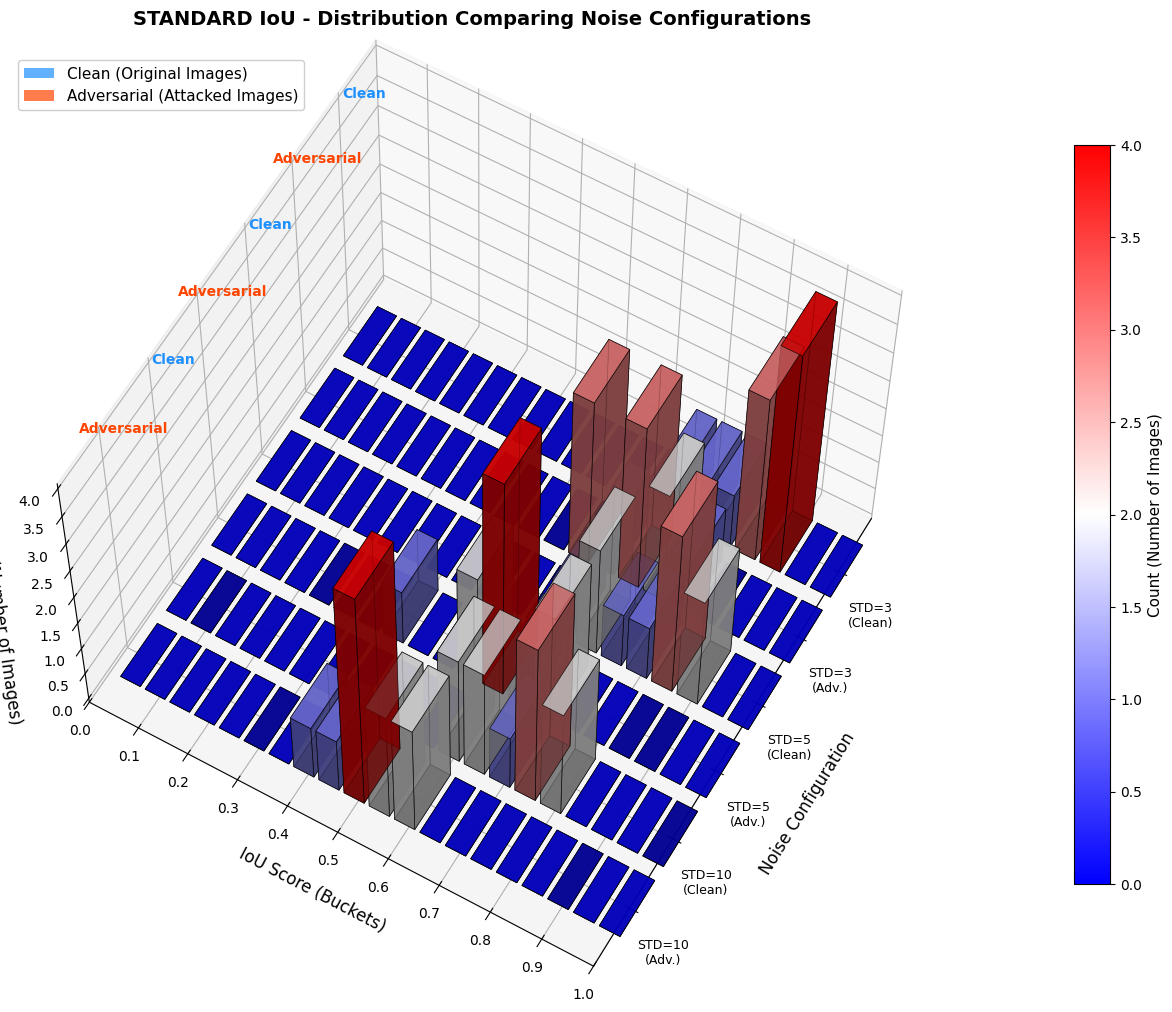


STANDARD - 3D HISTOGRAM STATISTICS

GAUSSIAN STD3:
  Clean: Mean=0.812, Std=0.068, n=10
  Adv:   Mean=0.655, Std=0.066, n=10

GAUSSIAN STD5:
  Clean: Mean=0.764, Std=0.088, n=10
  Adv:   Mean=0.566, Std=0.081, n=10

GAUSSIAN STD10:
  Clean: Mean=0.684, Std=0.063, n=10
  Adv:   Mean=0.495, Std=0.058, n=10


C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr')
C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


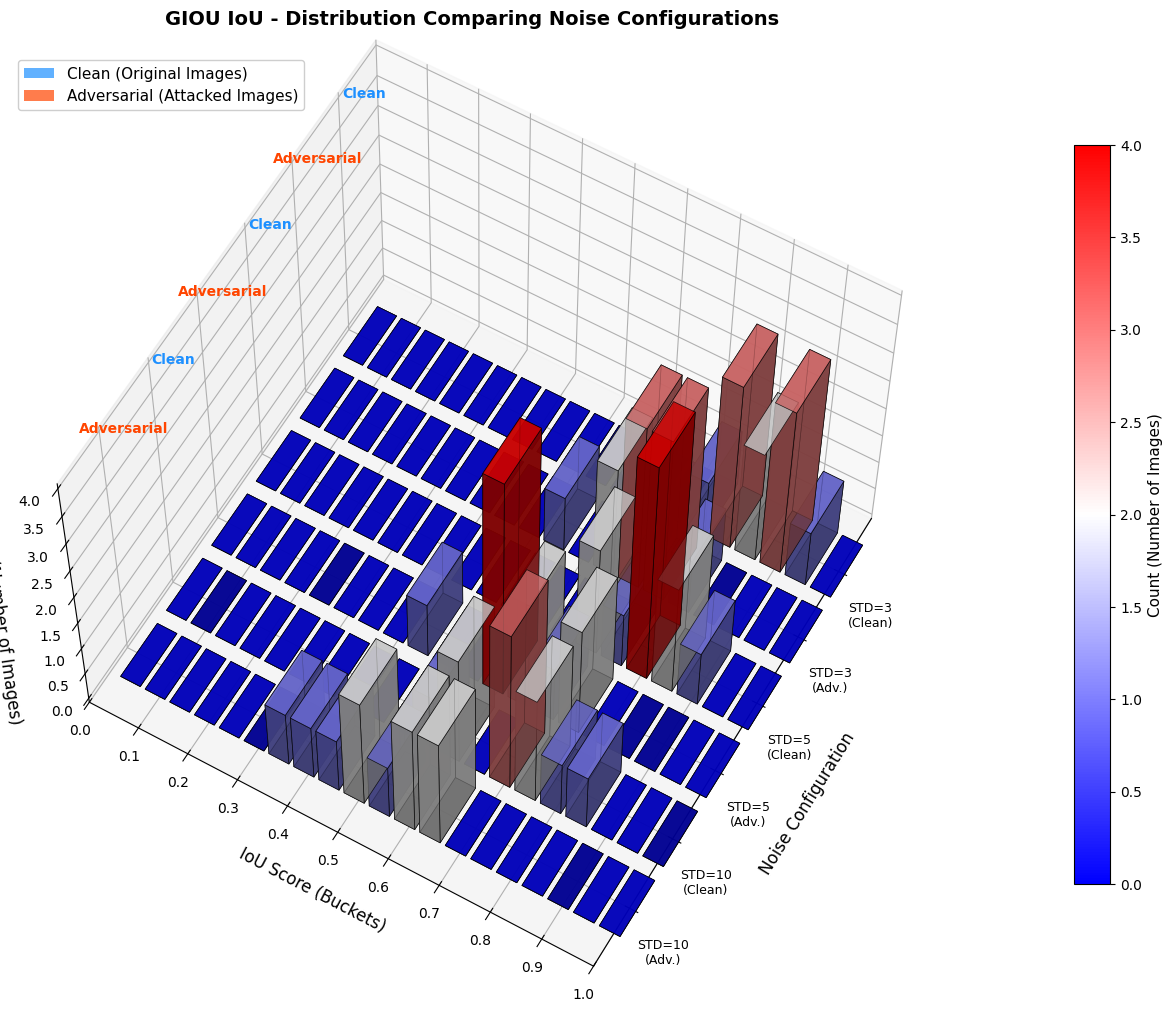


GIOU - 3D HISTOGRAM STATISTICS

GAUSSIAN STD3:
  Clean: Mean=0.833, Std=0.053, n=10
  Adv:   Mean=0.679, Std=0.061, n=10

GAUSSIAN STD5:
  Clean: Mean=0.767, Std=0.065, n=10
  Adv:   Mean=0.609, Std=0.085, n=10

GAUSSIAN STD10:
  Clean: Mean=0.674, Std=0.088, n=10
  Adv:   Mean=0.504, Std=0.102, n=10


C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr')
C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


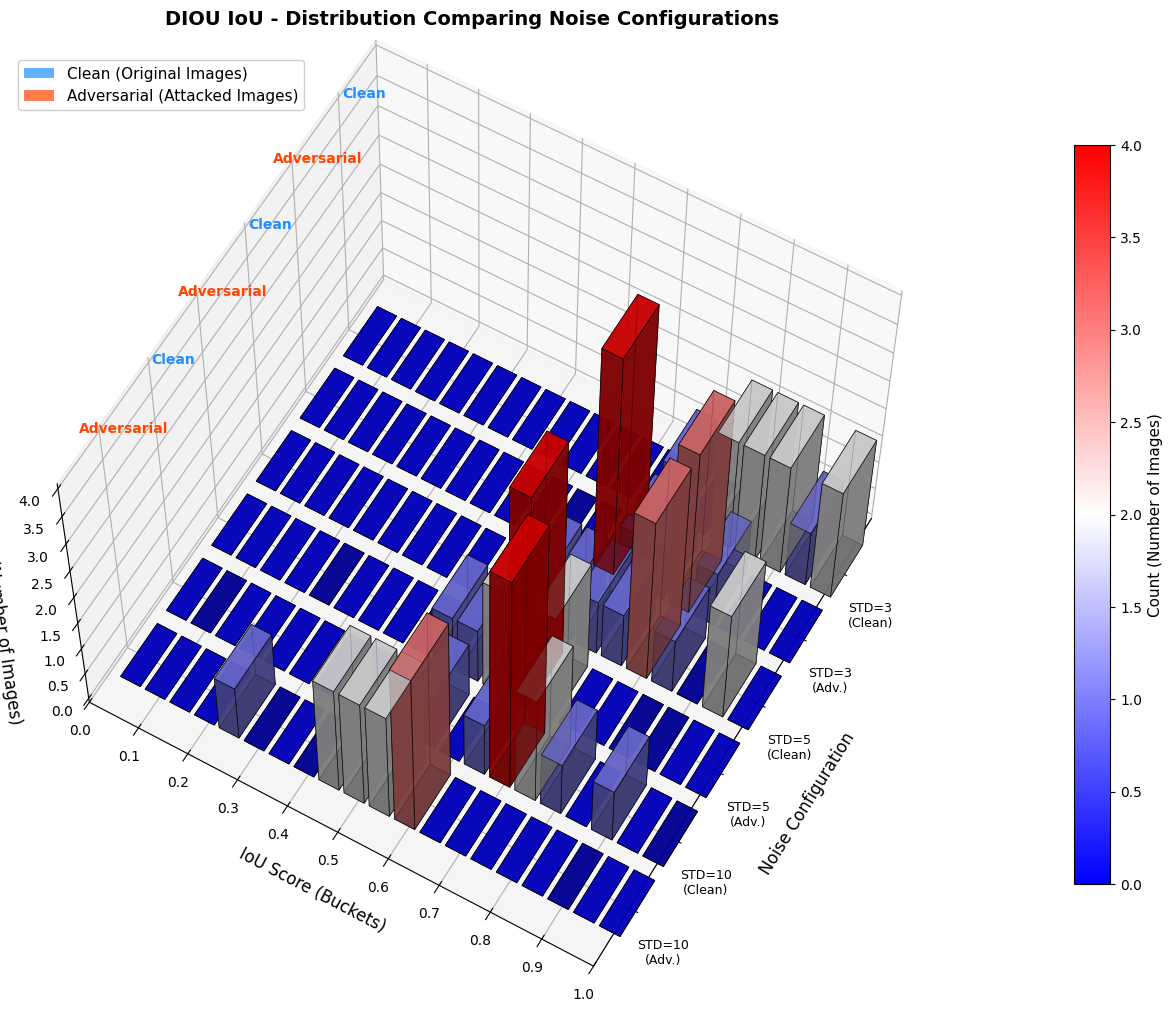


DIOU - 3D HISTOGRAM STATISTICS

GAUSSIAN STD3:
  Clean: Mean=0.848, Std=0.081, n=10
  Adv:   Mean=0.699, Std=0.077, n=10

GAUSSIAN STD5:
  Clean: Mean=0.773, Std=0.108, n=10
  Adv:   Mean=0.602, Std=0.055, n=10

GAUSSIAN STD10:
  Clean: Mean=0.690, Std=0.087, n=10
  Adv:   Mean=0.484, Std=0.098, n=10


C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr')
C:\Users\victo\AppData\Local\Temp\ipykernel_17972\3510739868.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


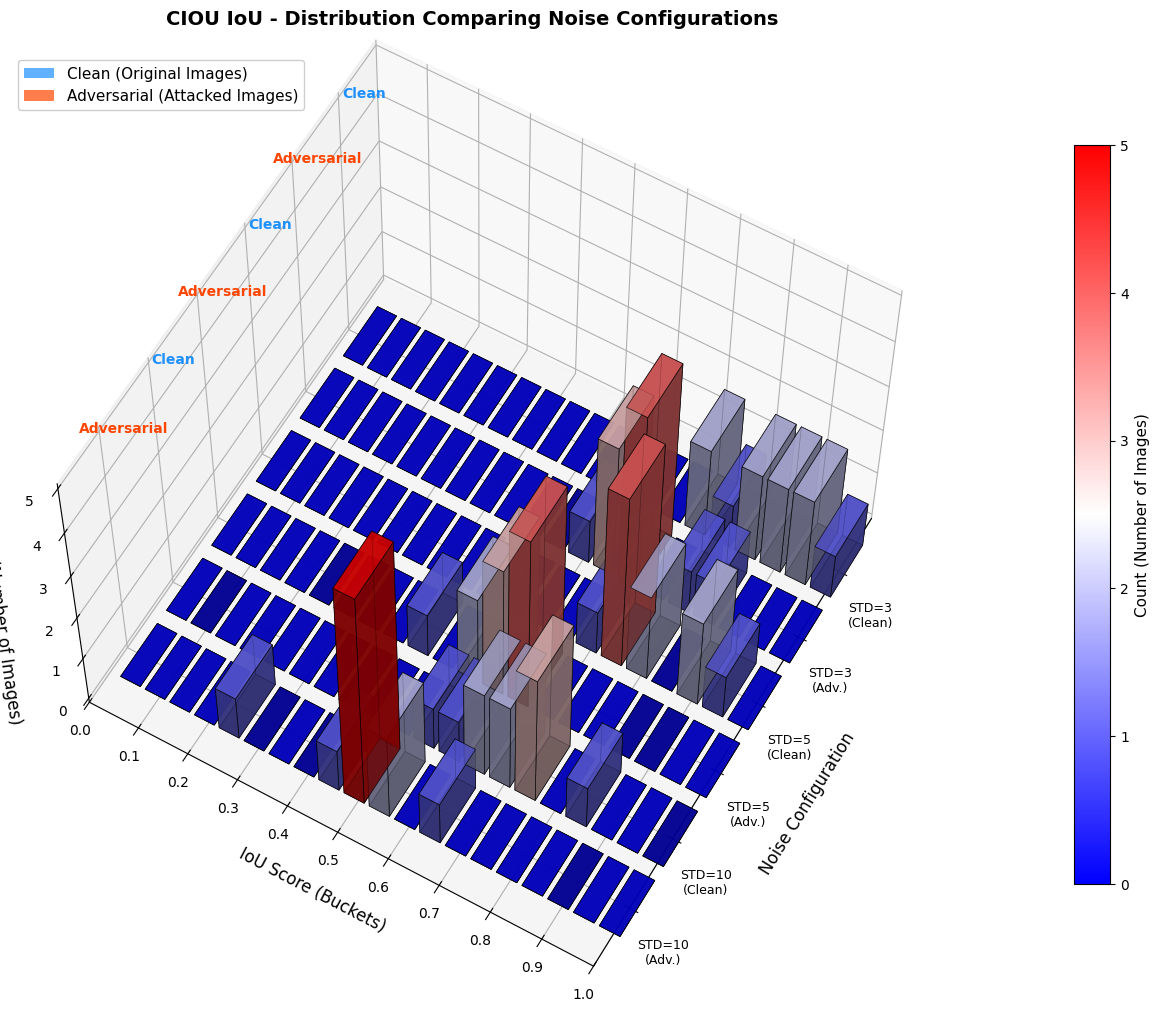


CIOU - 3D HISTOGRAM STATISTICS

GAUSSIAN STD3:
  Clean: Mean=0.844, Std=0.075, n=10
  Adv:   Mean=0.672, Std=0.062, n=10

GAUSSIAN STD5:
  Clean: Mean=0.777, Std=0.078, n=10
  Adv:   Mean=0.566, Std=0.064, n=10

GAUSSIAN STD10:
  Clean: Mean=0.678, Std=0.086, n=10
  Adv:   Mean=0.477, Std=0.094, n=10


In [ ]:
noise_configs = [
    {'type': 'speckle', 'mean': 0, 'std': 3},
    {'type': 'speckle', 'mean': 0, 'std': 5},
    {'type': 'speckle', 'mean': 0, 'std': 10}
]
iou_types = ["standard", "giou", "diou", "ciou"]
detector = AdversarialObjectDetection()
guassian1 = batch_test_with_loops(
    detector=detector,
    image_paths=test_images,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    iou_types=iou_types,
    num_iterations=3,
    confidence_threshold=0.5
)
compare_iou_types_plot_3d_bars(guassian1,azim=30)